In [1]:
import requests
import h5py
import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as sci
from scipy.stats import binned_statistic_2d
from matplotlib.colors import LogNorm
from scipy.ndimage import gaussian_filter

In [2]:
baseUrl = 'http://www.tng-project.org/api/'
headers = {"api-key":"e7205be31fb9f9b069960f52cf1481c1"}

In [3]:
h=0.6774
sn,scales,zs=np.loadtxt("redshifts.dat",unpack=True)

In [4]:
def factors(snap):
   a=scales[snap]
   aa=np.sqrt(a)
   redshift=zs[snap]
   scalefactor=1./(1+redshift)
   kpc=scalefactor/h
   return aa, kpc

In [5]:
def get(path, params=None):
    # make HTTP GET request to path
    r = requests.get(path, params=params, headers=headers)

    # raise exception if response code is not HTTP SUCCESS (200)
    r.raise_for_status()

    if r.headers['content-type'] == 'application/json':
        return r.json() # parse json responses automatically

    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        return filename # return the filename string

    return r

In [6]:
def download(subid,snapnum,nameid):
    aa,kpc=factors(snapnum)

    url = "http://www.tng-project.org/api/TNG50-1/snapshots/"+str(snapnum)+"/subhalos/"+str(subid)
    sub=get(url)

    if sub['len_stars']>0:
       cutout_stars={'stars':'Coordinates,Masses,Velocities,GFM_StellarFormationTime,ParticleIDs'}    
       stars=get(url+"/cutout.hdf5",cutout_stars)    
       with h5py.File(stars,'r+') as f:
           x = f['PartType4']['Coordinates'][:,0] - sub['pos_x']
           y = f['PartType4']['Coordinates'][:,1] - sub['pos_y']
           z = f['PartType4']['Coordinates'][:,2] - sub['pos_z']
           masses=f['PartType4']['Masses'][:]
           vx = aa*f['PartType4']['Velocities'][:,0] - sub['vel_x']
           vy = aa*f['PartType4']['Velocities'][:,1] - sub['vel_y']
           vz = aa*f['PartType4']['Velocities'][:,2] - sub['vel_z']
           t=f['PartType4']['GFM_StellarFormationTime'][:]
       outdat=np.transpose((masses/h,x*kpc,y*kpc,z*kpc,vx,vy,vz,t))
       np.savetxt('discs/stars_'+str(nameid)+'_snap_'+str(snapnum)+'.txt', outdat)
       return outdat

In [7]:
def cent1(m,x,y,z,Rbig,dR,Rsmall,vx,vy,vz,Rvel):
    xc0=0.
    yc0=0.
    zc0=0.

    R=Rbig
    xc1=xc0
    yc1=yc0
    zc1=zc0

    while R>=Rsmall:
        xin=[]
        yin=[]
        zin=[]
        mins=[]
        for i in range(len(x)):
            r=np.sqrt((x[i]-xc1)**2+(y[i]-yc1)**2+(z[i]-zc1)**2)  
            if r<=R:
                xin.append(x[i])
                yin.append(y[i])
                zin.append(z[i])
                mins.append(m[i])
        xc1=np.average(xin,weights=mins)
        yc1=np.average(yin,weights=mins)
        zc1=np.average(zin,weights=mins)
        R=R-dR

    vxin=[]
    vyin=[]
    vzin=[]
    mvel=[]
    for i in range(len(x)):
        r=np.sqrt((x[i]-xc1)**2+(y[i]-yc1)**2+(z[i]-zc1)**2)
        if r<=Rvel:
            vxin.append(vx[i])
            vyin.append(vy[i])
            vzin.append(vz[i])
            mvel.append(m[i])

    vxc=np.average(vxin,weights=mvel)
    vyc=np.average(vyin,weights=mvel)
    vzc=np.average(vzin,weights=mvel)
    return xc1,yc1,zc1,vxc,vyc,vzc

In [8]:
def get_rotation_matrix(i_v, unit=None):
    # From http://www.j3d.org/matrix_faq/matrfaq_latest.html#Q38
    if unit is None:
        unit = [1.0, 0.0, 0.0]
    # Normalize vector length
    i_v /= np.linalg.norm(i_v)

    # Get axis
    uvw = np.cross(i_v, unit)

    # compute trig values - no need to go through arccos and back
    rcos = np.dot(i_v, unit)
    rsin = np.linalg.norm(uvw)

    #normalize and unpack axis
    if not np.isclose(rsin, 0):
        uvw /= rsin
    u, v, w = uvw

    # Compute rotation matrix - re-expressed to show structure
    return (
        rcos * np.eye(3) +
        rsin * np.array([
            [ 0, -w,  v],
            [ w,  0, -u],
            [-v,  u,  0]
        ]) +
        (1.0 - rcos) * uvw[:,None] * uvw[None,:]
    )

In [7]:
filename = 'stellar_circs.hdf5'
f = h5py.File(filename, 'r')

disks=[]



for i in range((len(f['Snapshot_99']['MassTensorEigenVals']))): #len(f['Snapshot_99']['MassTensorEigenVals']) total number of tensors(disks)

    m1=f['Snapshot_99']['MassTensorEigenVals'][i][0]
    m2=f['Snapshot_99']['MassTensorEigenVals'][i][1]
    m3=f['Snapshot_99']['MassTensorEigenVals'][i][2]
    #print(m1,m2,m3)
    flatness=m1/np.sqrt(m2*m3)
    if flatness<0.7:
       disks.append(f['Snapshot_99']['SubfindID'][i]) #id of the disks with the criteria

print(len(disks)/len(f['Snapshot_99']['MassTensorEigenVals'])) #nomber of disks with flatness<0.7/ total number of disks

np.savetxt('disk_ax.dat',disks)

0.510501012145749


In [8]:
filename = 'stellar_circs.hdf5'
f = h5py.File(filename, 'r')

disks=[]

for i in range(len(f['Snapshot_99']['CircAbove07Frac'])): # len(f['Snapshot_99']['CircAbove07Frac']) total number of disks with epsilon>0.7
     if f['Snapshot_99']['CircAbove07Frac'][i]>0.2:
          disks.append(f['Snapshot_99']['SubfindID'][i])  #id of the disks with the criteria
print(len(disks)/len(f['Snapshot_99']['CircAbove07Frac'])) #nomber of disks with >0.2/ total number of disks with epsilon>0.7

np.savetxt('disk_circ.dat',disks)

0.45736336032388664


In [10]:
h=0.6774
sim="TNG50-1"

mass_min = (10**11) / 1e10 * h
mass_max = 5*(10**12) / 1e10 * h

stars_min= 10**10.8 / 1e10 * h
#stars_max= 15*(10**10) / 1e10 *h

search_query = "?mass__gt=" + str(mass_min) + "&mass__lt=" + str(mass_max)


url = "http://www.tng-project.org/api/"+sim+"/snapshots/99/subhalos/" + search_query
subhalos = get(url,{'limit':5000} )


print(len(subhalos['results'])) #number of subhalos with the criteria
totdm=subhalos['count']         #number of subhalos with the criteria

dm_stars=[]

i=0
while i<totdm:
    current=get(subhalos['results'][i]['url'])
    mstars=current['mass_stars']
    if mstars>stars_min:
#        print(current['len_dm']/(10**6),current['mass_dm']/h)
        dm_stars.append([current['id'],mstars/h,current['halfmassrad_stars'],current['len_stars']])
        np.savetxt('mass_cuts.txt', dm_stars)
    i=i+1

2008


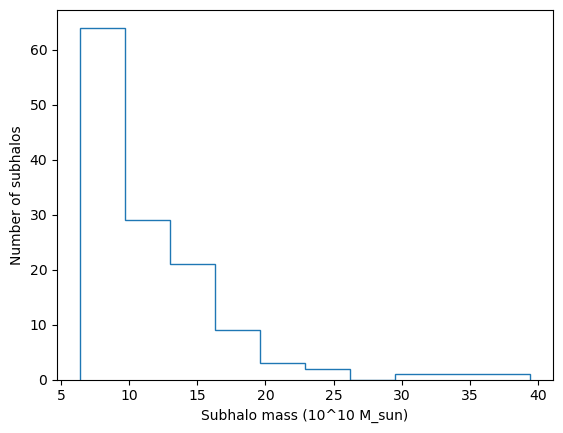

In [9]:
disk_ax_id = np.loadtxt("disk_ax.dat")
disk_circ_id = np.loadtxt("disk_circ.dat")
mass_cuts_id = np.loadtxt("mass_cuts.txt")[:,0]
mass_cuts_mass = np.loadtxt("mass_cuts.txt")[:,1]

common_id = list(set(disk_ax_id) & set(disk_circ_id) & set(mass_cuts_id))


def get_index(mass_cuts_id, common_id):
    index = []
    for i in range(len(common_id)):
        ind = np.where(mass_cuts_id == common_id[i])
        index.append(ind)
    return index

index = get_index(mass_cuts_id, common_id)

mass_cuts_common = []

for i in index:
    mass_cuts_common.append(mass_cuts_mass[i])

mass_cuts_common = np.concatenate(mass_cuts_common)

hist,bin_edges = np.histogram(mass_cuts_common,bins=10)   


plt.ylabel("Number of subhalos")
plt.xlabel("Subhalo mass (10^10 M_sun)")
plt.stairs(hist,bin_edges)
plt.show()

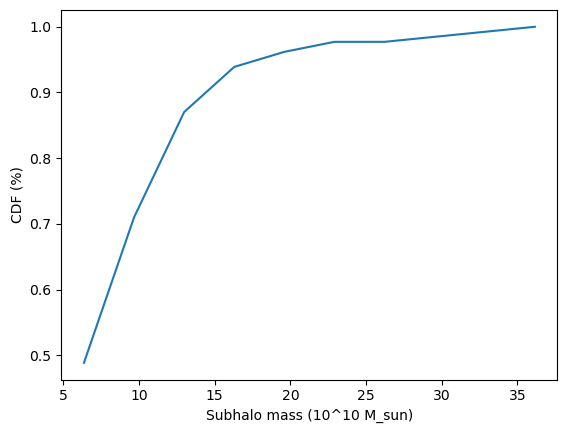

In [10]:
prob = hist/sum(hist)  
cumprob = np.cumsum(prob) 


plt.ylabel("CDF (%)")
plt.xlabel("Subhalo mass (10^10 M_sun)")
plt.plot(bin_edges[:-1],cumprob)
plt.show()

In [11]:
mass_cuts_ordered = np.sort(mass_cuts_common)[::-1]
mass_10max = mass_cuts_ordered[:10]

index_10max = get_index(mass_cuts_mass,mass_10max)

id_10max = []

for i in index_10max:
    id_10max.append(mass_cuts_id[i])

index_10max = np.concatenate(index_10max)    
index_10max = np.concatenate(index_10max)
id_10max = np.concatenate(id_10max)

print(id_10max,index_10max)

[1.00000e+00 6.38650e+04 3.07486e+05 6.38660e+04 2.42790e+05 1.43885e+05
 1.43883e+05 4.10037e+05 1.17252e+05 2.00000e+00] [ 0  7 45  8 37 22 20 75 15  1]


In [12]:
def get_data(subid,snapnum,nameid,index):
    
    download(int(subid),snapnum,nameid)
    
    data = np.loadtxt('discs/stars_'+str(nameid)+'_snap_'+str(snapnum)+'.txt')
    
    m = data[:, 0]
    x = data[:, 1]
    y = data[:, 2]
    z = data[:, 3]
    vx = data[:, 4]
    vy = data[:, 5]
    vz = data[:, 6]
    t = data[:, 7]
    
    RS = np.loadtxt("mass_cuts.txt")[:,2][index]
    
    Rbig=5*RS
    Rsmall=.25*RS
    dR=(Rbig-Rsmall)/20
    Rvel=RS
    
    new_coord = cent1(m,x,y,z,Rbig,dR,Rsmall,vx,vy,vz,Rvel)

    x_centered = x-new_coord[0]
    y_centered = y-new_coord[1]
    z_centered = z-new_coord[2]
    vx_centered = vx-new_coord[3]
    vy_centered = vy-new_coord[4]
    vz_centered = vz-new_coord[5]

    dist = np.sqrt(x**2 + y**2 + z**2)

    mask = dist < (2 * RS)

    m_cut = m[mask]
    x_cut = x_centered[mask]
    y_cut = y_centered[mask]
    z_cut = z_centered[mask]
    vx_cut = vx_centered[mask]
    vy_cut = vy_centered[mask]
    vz_cut = vz_centered[mask]

    r_vec = np.array([x_cut, y_cut, z_cut])
    v_vec = np.array([vx_cut, vy_cut, vz_cut])

    l_individual = m_cut[:, np.newaxis] *np.cross(r_vec.T, v_vec.T)

    L_total = np.sum(l_individual, axis=0)

    matrix_rot = get_rotation_matrix(L_total, [0,0,1])

    r_vec_tot = np.array([x_centered, y_centered, z_centered])
    v_vec_tot = np.array([vx_centered, vy_centered, vz_centered])
    
    r_rot = (matrix_rot @ r_vec_tot)
    v_rot = (matrix_rot @ v_vec_tot)

    x_rot = r_rot[0]
    y_rot = r_rot[1]
    z_rot = r_rot[2]
    vx_rot = v_rot[0]
    vy_rot = v_rot[1]
    vz_rot = v_rot[2]

    outdat_rot=np.transpose((m,x_rot,y_rot,z_rot,vx_rot,vy_rot,vz_rot,t))
    np.savetxt('discs/stars_'+str(nameid)+'_snap_'+str(snapnum)+"_rot"+'.txt', outdat_rot)

In [86]:
for i in range(len(index_10max)):
    get_data(id_10max[i],99,id_10max[i],index_10max[i])

<Figure size 640x480 with 0 Axes>

In [14]:
max_vrad = []
total_mass = []

for i in range(len(index_10max)):    
    data = np.loadtxt('discs/stars_'+str(id_10max[i])+'_snap_'+str(99)+"_rot"+'.txt')
    m = data[:, 0]
    x = data[:, 1]
    y = data[:, 2]
    vx = data[:, 4]
    vy = data[:, 5]
    vz = data[:, 6]
    
    rad = np.sqrt(x**2+y**2)
    v_rad = (x*vx+y*vy)/rad

    grid_resolution = 3000
    
    ret = binned_statistic_2d(x, y, 
    v_rad,            
    statistic='mean', 
    bins=grid_resolution
    )
    
    mean_vrad_map = ret.statistic
    
    max_vrad.append(np.nanmax(np.abs(mean_vrad_map)))
    total_mass.append(sum(m))  

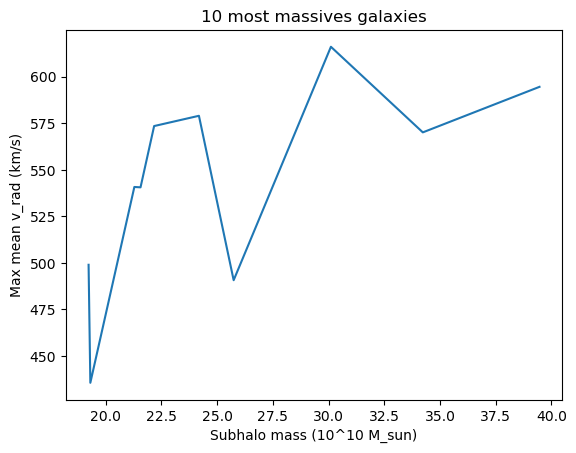

In [15]:
plt.title("10 most massives galaxies")
plt.ylabel("Max mean v_rad (km/s)")
plt.xlabel("Subhalo mass (10^10 M_sun)")
plt.plot(total_mass,max_vrad)
plt.show()

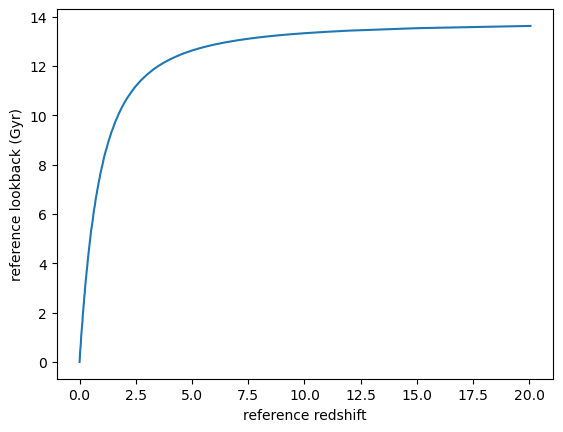

In [16]:
z_ref = [20.05,14.99,11.98,10.98,10.00,9.39,9.00,8.45,8.01,7.60,7.24,7.01,6.49,6.01,5.85,5.53,5.23,5.00,4.66,4.43,4.18,4.01,3.71,3.49,3.28,3.01,2.90,
         2.73,2.58,2.44,2.32,2.21,2.10,2.00,1.90,1.82,1.74,1.67,1.60,1.53,1.50,1.41,1.36,1.30,1.25,1.21,1.15,1.11,1.07,1.04,1.00,0.95,0.92,0.89,0.85,
         0.82,0.79,0.76,0.73,0.70,0.68,0.64,0.62,0.60,0.58,0.55,0.52,0.50,0.48,0.46,0.44,0.42,0.40,0.38,0.36,0.35,0.33,0.31,0.30,0.27,0.26,0.24,0.23,
         0.21,0.20,0.18,0.17,0.15,0.14,0.13,0.11,0.10,0.08,0.07,0.06,0.05,0.03,0.02,0.01,0.00]
t_ref = [13.624,13.532,13.433,13.385,13.328,13.286,13.256,13.207,13.163,13.116,13.071,13.039,12.959,12.871,12.838,12.767,12.691,12.626,12.521,
         12.437,12.337,12.263,12.115,11.991,11.859,11.658,11.565,11.419,11.264,11.118,10.964,10.823,10.674,10.519,10.356,10.210,10.059,9.901,9.766,9.597,
         9.510,9.301,9.147,8.987,8.823,8.688,8.514,8.372,8.226,8.077,7.925,7.730,7.610,7.447,7.281,7.111,6.981,6.805,6.671,6.489,6.350,6.161,6.017,5.872,
         5.724,5.523,5.371,5.216,5.060,4.901,4.741,4.578,4.414,4.247,4.079,3.966,3.794,3.621,3.504,3.269,3.149,2.969,2.787,2.665,2.480,2.294,2.169,1.979,
         1.852,1.660,1.466,1.336,1.140,1.008,0.810,0.676,0.475,0.340,0.136,0.00]

plt.xlabel("reference redshift")
plt.ylabel("reference lookback (Gyr)")
plt.plot(sorted(z_ref),sorted(t_ref))
plt.show()



In [17]:
def ages_cut(a,z_ref,t_ref,cut):
    z = 1/a-1
    t = np.interp(z,sorted(z_ref),sorted(t_ref))
    mask = t<cut
    return mask

In [60]:
for i in range(len(index_10max)):
    data = np.loadtxt('discs/stars_'+str(id_10max[i])+'_snap_'+str(99)+"_rot"+'.txt')

    a = data[:, 7]
    cut = 10
    mask = ages_cut(a,z_ref,t_ref,cut)
    
    m = data[:, 0][mask]
    x = data[:, 1][mask]
    y = data[:, 2][mask]

    grid_resolution = 3000

    ret = binned_statistic_2d(x, y, 
        m,            
        statistic='sum', 
        bins=grid_resolution
    )
    
    mass_map = ret.statistic
    x_edges = ret.x_edge
    y_edges = ret.y_edge
    
    smoothed_density = gaussian_filter(mass_map, sigma=1.5)
    
    limit = 25 # Adjust this based on your galaxy's expected size
    
    plt.xlim(-limit, limit)
    plt.ylim(-limit, limit)
    plt.xlabel("x(kpc)")
    plt.ylabel("y(kpc)")
    plt.title("M_star="+str(round(sum(m)))+" (10^10Msun) lookback<10")
    plt.imshow(smoothed_density.T, origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],cmap='magma',norm=LogNorm(vmin=1e-6, vmax=2e-1))
    plt.colorbar(label='Mass density (10^10 MSun)')
    plt.savefig("images_10max/mass_" + str(id_10max[i]) + ".png", dpi=300, bbox_inches='tight')
    plt.clf()

<Figure size 640x480 with 0 Axes>

In [61]:
for i in range(len(index_10max)):
    data = np.loadtxt('discs/stars_'+str(id_10max[i])+'_snap_'+str(99)+"_rot"+'.txt')

    a = data[:, 7]
    cut = 10
    mask = ages_cut(a,z_ref,t_ref,cut)
    
    m = data[:, 0][mask]
    x = data[:, 1][mask]
    y = data[:, 2][mask]
    vx = data[:, 4][mask]
    vy = data[:, 5][mask]

    rad = np.sqrt(x**2+y**2)
    v_rad = (x*vx+y*vy)/rad
    
    grid_resolution = 3000
    
    ret = binned_statistic_2d(x, y, 
    v_rad,            
    statistic='mean', 
    bins=grid_resolution
    )
    
    mean_vrad_map = ret.statistic
    x_edges = ret.x_edge
    y_edges = ret.y_edge
    
    
    smoothed_vrad_map = gaussian_filter(mean_vrad_map, sigma=1.5)
    
    limit = 15  # Adjust this based on your galaxy's expected size
    plt.title("M_star="+str(round(sum(m)))+" (10^10Msun) lookback<10")
    plt.xlim(-limit, limit)
    plt.ylim(-limit, limit)
    plt.xlabel("x(kpc)")
    plt.ylabel("y(kpc)")
    plt.imshow(smoothed_vrad_map.T, origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],cmap='RdBu_r',zorder=1)
    plt.colorbar(label='Mean v_rad (km/s)')

    plt.savefig("images_10max/mean_vrad_" + str(id_10max[i]) + ".png", dpi=300, bbox_inches='tight')
    plt.clf()

<Figure size 640x480 with 0 Axes>

In [38]:
id_random = np.random.choice(common_id,size=10,replace = False)

In [67]:
id_random = [394622.0, 371127.0, 479290.0, 452031.0, 447914.0, 386269.0, 439099.0, 503437.0, 471248.0,
 394621.0]

In [68]:
print(id_random)

[394622.0, 371127.0, 479290.0, 452031.0, 447914.0, 386269.0, 439099.0, 503437.0, 471248.0, 394621.0]


In [22]:
index_random = get_index(mass_cuts_id,id_random)

In [23]:
print(index_random)

[(array([66]),), (array([54]),), (array([129]),), (array([106]),), (array([102]),), (array([61]),), (array([97]),), (array([152]),), (array([122]),), (array([65]),)]


In [42]:
for i in range(len(index_random)):
    get_data(id_random[i],99,id_random[i],index_random[i])

In [46]:
for i in range(len(index_random)):
    data = np.loadtxt('discs/stars_'+str(id_random[i])+'_snap_'+str(99)+"_rot"+'.txt')

    #a = data[:, 7]
    #cut = 8
    #mask = ages_cut(a,z_ref,t_ref,cut)
    
    #m = data[:, 0][mask]
    #x = data[:, 1][mask]
    #y = data[:, 2][mask]
    
    m = data[:, 0]
    x = data[:, 1]
    y = data[:, 2]
    
    grid_resolution = 3000

    ret = binned_statistic_2d(x, y, 
        m,            
        statistic='sum', 
        bins=grid_resolution
    )
    
    mass_map = ret.statistic
    x_edges = ret.x_edge
    y_edges = ret.y_edge
    
    smoothed_density = gaussian_filter(mass_map, sigma=1.5)
    
    limit = 50 # Adjust this based on your galaxy's expected size
    
    plt.xlim(-limit, limit)
    plt.ylim(-limit, limit)
    plt.xlabel("x(kpc)")
    plt.ylabel("y(kpc)")
    plt.title("Mass distribution M_star="+str(round(sum(m)))+" (10^10Msun)")
    plt.imshow(smoothed_density.T, origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],cmap='magma',norm=LogNorm(vmin=1e-6, vmax=2e-1))
    plt.colorbar(label='Mass density (10^10 MSun)')
    plt.savefig("images_random/mass_" + str(id_random[i]) + ".png", dpi=300, bbox_inches='tight')
    plt.clf()

<Figure size 640x480 with 0 Axes>

In [52]:
for i in range(len(index_random)):
    data = np.loadtxt('discs/stars_'+str(id_random[i])+'_snap_'+str(99)+"_rot"+'.txt')

    #a = data[:, 7]
    #cut = 8
    #mask = ages_cut(a,z_ref,t_ref,cut)
    
    #m = data[:, 0][mask]
    #x = data[:, 1][mask]
    #y = data[:, 2][mask]
    #vx = data[:, 4][mask]
    #vy = data[:, 5][mask]
    
    m = data[:, 0]
    x = data[:, 1]
    y = data[:, 2]
    vx = data[:, 4]
    vy = data[:, 5]
    
    rad = np.sqrt(x**2+y**2)
    v_rad = (x*vx+y*vy)/rad
    
    grid_resolution = 3000
    
    ret = binned_statistic_2d(x, y, 
    v_rad,            
    statistic='mean', 
    bins=grid_resolution
    )
    
    mean_vrad_map = ret.statistic
    x_edges = ret.x_edge
    y_edges = ret.y_edge
    
    
    smoothed_vrad_map = gaussian_filter(mean_vrad_map, sigma=1.5)
    
    limit = 25  # Adjust this based on your galaxy's expected size
    
    plt.xlim(-limit, limit)
    plt.ylim(-limit, limit)
    plt.title("Mean radial velocity M_star="+str(round(sum(m)))+" (10^10Msun)")
    plt.xlabel("x(kpc)")
    plt.ylabel("y(kpc)")
    plt.imshow(smoothed_vrad_map.T, origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],cmap='RdBu_r',zorder=1)
    plt.colorbar(label='Mean v_rad (km/s)')

    plt.savefig("images_random/mean_vrad_" + str(id_random[i]) + ".png", dpi=300, bbox_inches='tight')
    plt.clf()

<Figure size 640x480 with 0 Axes>

In [47]:
max_vrad_rnd = []
total_mass_rnd = []

for i in range(len(index_random)):    
    data = np.loadtxt('discs/stars_'+str(id_random[i])+'_snap_'+str(99)+"_rot"+'.txt')
    
    m = data[:, 0]
    x = data[:, 1]
    y = data[:, 2]
    vx = data[:, 4]
    vy = data[:, 5]


    rad = np.sqrt(x**2+y**2)
    v_rad = (x*vx+y*vy)/rad

    ret = binned_statistic_2d(x, y, 
    v_rad,            
    statistic='mean', 
    bins=grid_resolution
    )
    
    mean_vrad_map = ret.statistic
    
    max_vrad_rnd.append(np.nanmax(np.abs(mean_vrad_map)))
    total_mass_rnd.append(sum(m))  

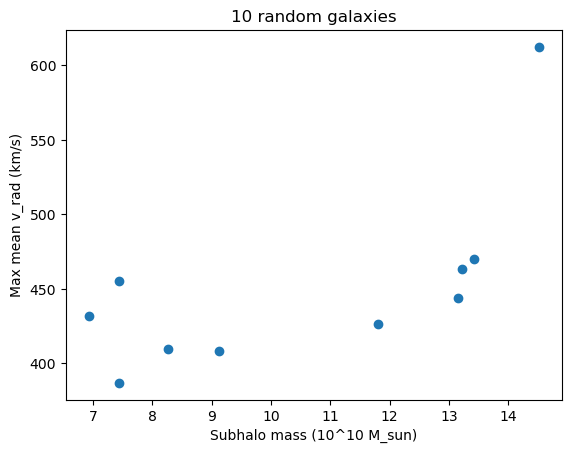

In [49]:
plt.title("10 random galaxies")
plt.ylabel("Max mean v_rad (km/s)")
plt.xlabel("Subhalo mass (10^10 M_sun)")
plt.scatter(total_mass_rnd,max_vrad_rnd)
plt.show()

In [65]:
for i in range(len(index_10max)):    
    data = np.loadtxt('discs/stars_'+str(id_10max[i])+'_snap_'+str(99)+"_rot"+'.txt')
    
    RS = np.loadtxt("mass_cuts.txt")[:,2][i]
    
    m = data[:, 0]
    x = data[:, 1]
    y = data[:, 2]
    
    rad = np.sqrt(x**2+y**2) 
    
    num_bins = 50
    
    bin_edges = np.linspace(0, 5 * RS, num_bins)
    
    sigma = []
    
    for j in range(1,len(bin_edges)):
        ring_area = (bin_edges[j]**2-bin_edges[j-1]**2)*np.pi
        
        mask_ring = (rad >= bin_edges[j-1]) & (rad < bin_edges[j])
    
        ring_mass = np.sum(m[mask_ring])
        
        sigma.append(ring_mass/ring_area)
        
    plt.title("394621 subhalo M_star="+str(round(sum(m)))+" (10^10Msun)")
    plt.xlabel("R (kpc)")
    plt.ylabel(r"$log_{10}(\sigma) (\frac{(10^10M_{sun})}{kpc^2})$")
    plt.scatter(bin_edges[1:],np.log10(sigma))
    plt.savefig("density_profiles/density_" + str(id_10max[i]) + ".png", dpi=300, bbox_inches='tight')
    plt.clf()

<Figure size 640x480 with 0 Axes>

In [59]:
print(len(bin_edges),len(sigma))

50 49


In [69]:
for i in range(len(index_random)):    
    data = np.loadtxt('discs/stars_'+str(id_random[i])+'_snap_'+str(99)+"_rot"+'.txt')
    
    RS = np.loadtxt("mass_cuts.txt")[:,2][i]
    
    m = data[:, 0]
    x = data[:, 1]
    y = data[:, 2]
    
    rad = np.sqrt(x**2+y**2) 
    
    num_bins = 50
    
    bin_edges = np.linspace(0, 5 * RS, num_bins)
    
    sigma = []
    
    for j in range(1,len(bin_edges)):
        ring_area = (bin_edges[j]**2-bin_edges[j-1]**2)*np.pi
        
        mask_ring = (rad >= bin_edges[j-1]) & (rad < bin_edges[j])
    
        ring_mass = np.sum(m[mask_ring])
        
        sigma.append(ring_mass/ring_area)
        
    plt.title("394621 subhalo M_star="+str(round(sum(m)))+" (10^10Msun)")
    plt.xlabel("R (kpc)")
    plt.ylabel(r"$log_{10}(\sigma) (\frac{(10^10M_{sun})}{kpc^2})$")
    plt.scatter(bin_edges[1:],np.log10(sigma))
    plt.savefig("density_profiles/density_" + str(id_random[i]) + ".png", dpi=300, bbox_inches='tight')
    plt.clf()

<Figure size 640x480 with 0 Axes>